
# **Include any disclaimers about the use of AI and cite the parts of the code that AI have been used for.**

LLM Usage (Queries):
1. How does unsqueeze(1) work? (used in tensor creation in Data Loading and Preprocessing)
2. What is a general form to define neural networks in Python? (helped with formation of BreastCancerNN and FeedForwardNetWithDropout classes)
3. How do .train(), .backward(), .step() work in reference to Neural Networks in pytorch? (used various times within functions for training)
4. What does .state_dict() do exactly? (used in function stochastic_gradient_descent)
5. How does dropout work in pytorch? (used in FeedForwardNetWithDropout class and related functions)
6. What does .item() do in python? (used to understand its usage within functions)

Total CO2 usage: 4.32g * 6 queries = 25.92g

In [23]:
import sys
if not sys.version.startswith("3.12"):
    raise RuntimeError("This notebook requires Python 3.12")

# !pip install numpy pandas matplotlib seaborn scikit-learn torch platform psutil getpass

# Hardware and user spercifications

import platform
import psutil
import getpass

# --- Setup: Imports ---
import os, seaborn, sklearn, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# PyTorch imports
import torch
import torch.nn as nn
import torch.optim as optim

# Scikit-learn imports
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, recall_score, precision_score
from sklearn.utils import shuffle

#CODE HERE (optional): import any module needed from sklearn package
from sklearn.datasets import load_breast_cancer

def print_system_info():
    print("="*60)
    print("SYSTEM INFORMATION")
    print("="*60)

    # OS and hardware
    print(f"Operating System : {platform.system()} {platform.release()}")
    print(f"Processor        : {platform.processor()}")
    print(f"CPU Cores        : {psutil.cpu_count(logical=True)}")
    print(f"RAM              : {round(psutil.virtual_memory().total / (1024**3), 2)} GB")

    # User
    print(f"PC Username      : {getpass.getuser()}")

    # Python and environment
    print(f"Python Version   : {platform.python_version()}")
    print(f"Working Dir      : {os.getcwd()}")

    # GPU (if PyTorch is installed)
    if torch.cuda.is_available():
        print(f"GPU Device       : {torch.cuda.get_device_name(0)}")
        print(f"CUDA Version     : {torch.version.cuda}")
    else:
        print("GPU Device       : None (CPU mode)")

    print("="*60)
    print()

print_system_info()

# Set a random seed for reproducibility
random_seed = 42
torch.manual_seed(random_seed)
np.random.seed(random_seed)
random.seed(random_seed)

SYSTEM INFORMATION
Operating System : Windows 11
Processor        : Intel64 Family 6 Model 154 Stepping 3, GenuineIntel
CPU Cores        : 16
RAM              : 15.63 GB
PC Username      : Karm
Python Version   : 3.12.0
Working Dir      : c:\Users\Karm\Desktop\Fourth Year\Sfwreng 4AL3\Assignments\Assignment 3
GPU Device       : None (CPU mode)



Here, we load, split, scale the data. Then we convert them to PyTorch Tensors.

In [24]:
# --- Data Loading and Preprocessing ---

# CODE HERE: Load the dataset
data = load_breast_cancer()
X = data.data
y = data.target

# CODE HERE: Split the data (80% train, 20% validation). Set random_state=random_seed.

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=random_seed)

# CODE HERE: Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

# CODE HERE: Convert to PyTorch Tensors
X_train_t = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1) #unsqueeze makes shape [N, 1]
X_val_t = torch.tensor(X_val_scaled, dtype=torch.float32)
y_val_t = torch.tensor(y_val, dtype=torch.float32).unsqueeze(1)


print(f"Training features shape: {X_train_t.shape}")
print(f"Validation features shape: {X_val_t.shape}")

Training features shape: torch.Size([455, 30])
Validation features shape: torch.Size([114, 30])


Next, we define the Neural Network (NN).

In [25]:
# --- Model Definition ---

# CODE HERE: define the asked NN here
class BreastCancerNN(nn.Module):
    def __init__(self, input_size): # accept vector of size input_size
        super(BreastCancerNN, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(input_size, 32), #linear layer with 32 neurons
            nn.ReLU(),                 #ReLU activation function
            nn.Linear(32, 16),         #linear layer with 16 neurons
            nn.ReLU(),                 #ReLu activation function
            nn.Linear(16, 1),          #linear layer with 1 neuron
            nn.Sigmoid()               #sigmoid for probability of 1 or 0
        )
    def forward(self, x):
        return self.model(x)

input_features = X_train_t.shape[1]
print(f"Model will accept {input_features} input features.")
print("--- 3. Model Class Defined ---")

Model will accept 30 input features.
--- 3. Model Class Defined ---


Part 1:

In [26]:
def calculate_full_loss(model, criterion, X, y):
    """Helper function to calculate loss over an entire dataset."""
    model.eval() # Set model to evaluation mode
    with torch.no_grad(): # Disable gradient calculation
        outputs = model(X)
        loss = criterion(outputs, y)
    model.train() # Set model back to train mode
    return loss.item()

def stochastic_gradient_descent(model, criterion, optimizer, X_train, y_train, X_val, y_val,
                                max_iterations, check_every, patience, threshold):

    #CODE HERE: fill function. Use calculate_full_loss function for loss.
    train_losses = []
    val_losses = []
    best_val_loss = 10000000
    best_model_state = None
    iterations = []
    stop_iteration = max_iterations

    num_check_without_improve = 0

    for iteration in range(1, max_iterations + 1):
        # forward pass, compute loss for current batch
        optimizer.zero_grad() #clear gradient from last step
        outputs = model(X_train)
        loss = criterion(outputs, y_train)

        loss.backward() #backpropagate, compute gradients
        optimizer.step() # parameter update

        # every 'check_every' value, evaluate whole train and val loss
        if iteration % check_every == 0:
            train_loss = calculate_full_loss(model, criterion, X_train, y_train)
            val_loss = calculate_full_loss(model, criterion, X_val, y_val)
            
            train_losses.append(train_loss)
            val_losses.append(val_loss)
            iterations.append(iteration)

            #early stopping check
            if val_loss + threshold < best_val_loss:
                best_val_loss = val_loss
                best_model_state = model.state_dict() # save the best weights
                num_check_without_improve = 0
            else:
                num_check_without_improve += 1
                if (stop_iteration == max_iterations and num_check_without_improve >= patience):
                    stop_iteration = iteration
                
                # break

    return train_losses, val_losses, iterations, stop_iteration, best_model_state

Training and plot:

Plotting Part 1 results...


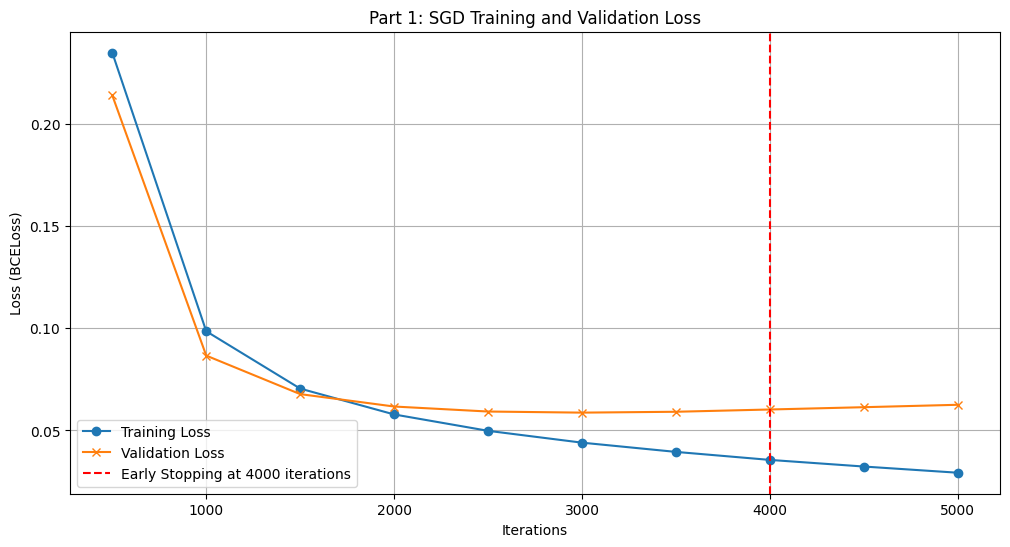


Accuracy of Early-Stopped Model on Validation Set: 98.25%


In [27]:
# --- Hyperparameters for Part 1 ---
LEARNING_RATE = 0.01
MAX_ITERATIONS = 5000
CHECK_EVERY = MAX_ITERATIONS // 10
PATIENCE = 3
THRESHOLD = 1e-3

# --- Model Initialization ---

#CODE HERE
model_sgd = BreastCancerNN(input_features)
criterion = torch.nn.BCELoss()
optimizer = torch.optim.SGD(model_sgd.parameters(), lr=LEARNING_RATE)

# --- Run Training ---

#CODE HERE
train_losses_sgd, val_losses_sgd, iterations_sgd, stop_iter, best_model_state = stochastic_gradient_descent(
                                                                                model_sgd, criterion, optimizer,
                                                                                X_train_t, y_train_t, X_val_t, y_val_t,
                                                                                max_iterations=MAX_ITERATIONS,
                                                                                check_every=CHECK_EVERY,
                                                                                patience=PATIENCE,
                                                                                threshold=THRESHOLD
)

#load best model for final validation
model_sgd.load_state_dict(best_model_state)

# --- Plotting Results ---
print("Plotting Part 1 results...")
plt.figure(figsize=(12, 6))
plt.plot(iterations_sgd, train_losses_sgd, label='Training Loss', marker='o')
plt.plot(iterations_sgd, val_losses_sgd, label='Validation Loss', marker='x')
plt.axvline(x=stop_iter, color='red', linestyle='--',
            label=f'Early Stopping at {stop_iter} iterations')
plt.title('Part 1: SGD Training and Validation Loss')
plt.xlabel('Iterations')
plt.ylabel('Loss (BCELoss)')
plt.legend()
plt.grid(True)
plt.show()

# --- Final Accuracy ---

#CODE HERE

with torch.no_grad():

    #CODE HERE
    model_sgd.eval()
    y_predicted_prob = model_sgd(X_val_t) # produces predicted probabilities
    y_predicted = (y_predicted_prob >= 0.5).int().numpy() # convert probabilities to 0 or 1
    y_true = y_val_t.numpy()

    accuracy = accuracy_score(y_true, y_predicted)
    print(f"\nAccuracy of Early-Stopped Model on Validation Set: {accuracy * 100:.2f}%")


Part 2:

In [28]:
def train_with_minibatch(model, criterion, optimizer, X_train, y_train, X_val, y_val,
                         num_iterations, batch_size, check_every):
    
    n = X_train.shape[0] # number of samples
    train_losses = []
    val_losses = []
    iterations = []

    # initially shuffle indices
    indices = torch.randperm(n)
    X_train_shuffled = X_train[indices]
    y_train_shuffled = y_train[indices]
    current_idx = 0

    for iteration in range(1, num_iterations + 1):
        # if end of an epoch is reached, reshuffle
        if current_idx + batch_size > n:
            X_train_np, y_train_np = shuffle(X_train_shuffled.numpy(), y_train_shuffled.numpy(),
                                            random_state=random_seed + iteration)
            X_train_shuffled = torch.tensor(X_train_np, dtype=torch.float32)
            y_train_shuffled = torch.tensor(y_train_np, dtype=torch.float32)
            current_idx = 0

        # prepare one batch
        batch_X = X_train_shuffled[current_idx:current_idx + batch_size]
        batch_Y = y_train_shuffled[current_idx:current_idx + batch_size]
        current_idx += batch_size

        optimizer.zero_grad()
        outputs = model(batch_X)
        loss = criterion(outputs, batch_Y)
        loss.backward()
        optimizer.step()

        # every 'check_every' value, evaluate train and val loss
        if iteration % check_every == 0:
            model.eval()
            with torch.no_grad():
                train_loss = calculate_full_loss(model, criterion, X_train, y_train)
                val_loss = calculate_full_loss(model, criterion, X_val, y_val)
            train_losses.append(train_loss)
            val_losses.append(val_loss)
            iterations.append(iteration)
            model.train()

    return train_losses, val_losses, iterations, model


Training and plot:

Plotting Part 2 comparison...


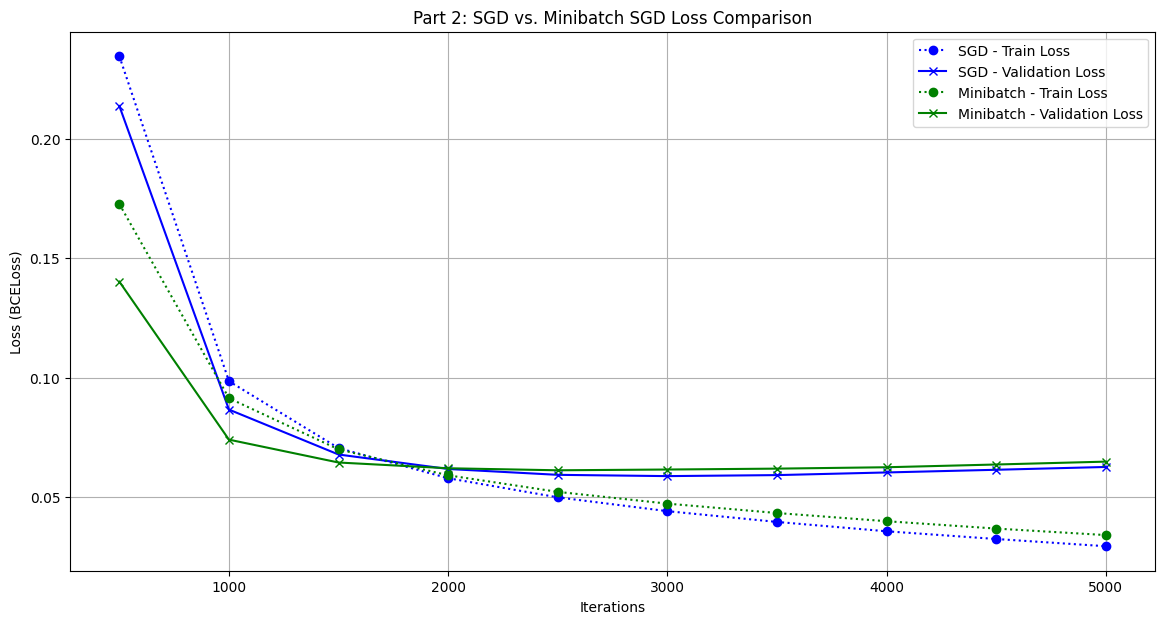

In [29]:
# --- Hyperparameters for Part 2 ---
LEARNING_RATE_MB = 0.01
NUM_ITERATIONS_MB = 5000
BATCH_SIZE = 32
CHECK_EVERY_MB = NUM_ITERATIONS_MB // 10 # plot every 5 epochs

# --- Model Initialization ---

#CODE HERE
model_mb = BreastCancerNN(input_features)
criterion_mb = torch.nn.BCELoss()
optimizer_mb = torch.optim.SGD(model_mb.parameters(), lr = LEARNING_RATE_MB)

# --- Run Minibatch Training ---

#CODE HERE
train_losses_mb, val_losses_mb, iterations_mb, model_mb_trained = train_with_minibatch(
    model_mb,
    criterion_mb,
    optimizer_mb,
    X_train_t,
    y_train_t,
    X_val_t,
    y_val_t,
    num_iterations=NUM_ITERATIONS_MB,      
    batch_size=BATCH_SIZE,
    check_every=CHECK_EVERY_MB
)

# --- Plotting Comparison ---
print("Plotting Part 2 comparison...")
plt.figure(figsize=(14, 7))

# SGD (Part 1)
plt.plot(iterations_sgd, train_losses_sgd, label='SGD - Train Loss', linestyle=':', color='blue', marker='o')
plt.plot(iterations_sgd, val_losses_sgd, label='SGD - Validation Loss', linestyle='-', color='blue', marker='x')

# Minibatch (Part 2)
plt.plot(iterations_mb, train_losses_mb, label='Minibatch - Train Loss', linestyle=':', color='green', marker='o')
plt.plot(iterations_mb, val_losses_mb, label='Minibatch - Validation Loss', linestyle='-', color='green', marker='x')

plt.title('Part 2: SGD vs. Minibatch SGD Loss Comparison')
plt.xlabel('Iterations')
plt.ylabel('Loss (BCELoss)')
plt.legend()
plt.grid(True)
plt.show()


Performance evaluation:

In [30]:
# --- Performance Metrics Comparison ---

def get_metrics(model, X_val, y_val):
    """Helper function to get accuracy, precision, and recall."""
    model.eval()
    with torch.no_grad():
        y_pred_prob = model(X_val)
        y_pred = (y_pred_prob > 0.5).int().numpy() # Convert to numpy
        y_true = y_val.numpy()

        acc = accuracy_score(y_true, y_pred)
        pre = precision_score(y_true, y_pred)
        rec = recall_score(y_true, y_pred)
    return acc, pre, rec

# Get metrics for Part 1 (Early-Stopped SGD Model)

#CODE HERE: USING get_metrics function
model_sgd.load_state_dict(best_model_state)
acc_sgd, pre_sgd, rec_sgd = get_metrics(model_sgd, X_val_t, y_val_t)

# Get metrics for Part 2 (Final Minibatch Model)

#CODE HERE: USING get_metrics function
acc_mb, pre_mb, rec_mb = get_metrics(model_mb_trained, X_val_t, y_val_t)

# --- Show Results in a Table ---
results = {
    'Metric': ['Accuracy', 'Precision', 'Recall'],
    'Part 1: Early-Stopped SGD': [f"{acc_sgd:.4f}", f"{pre_sgd:.4f}", f"{rec_sgd:.4f}"],
    'Part 2: Minibatch SGD': [f"{acc_mb:.4f}", f"{pre_mb:.4f}", f"{rec_mb:.4f}"]
}

results_df = pd.DataFrame(results)
print("\n--- Final Performance Metrics on Validation Set ---")

from IPython.display import display
display(results_df)



--- Final Performance Metrics on Validation Set ---


,Metric,Part 1: Early-Stopped SGD,Part 2: Minibatch SGD
0,Accuracy,0.9825,0.9825
1,Precision,0.9859,0.9859
2,Recall,0.9859,0.9859


# EXPLAIN HERE: Based on your experiments, answer the following questions:

1) How does early stopping affect the training and validation loss curves compared to training for all 5000 iterations?

Early stopping tries to prevent overfitting by stopping training when validation loss is no longer improving (plateaus or increases slowly) which ensures the model has generalized best performance. We can see in the Part1 graph that after 4000 iterations, the validation curve tends to move upwards which is why it is 'halted' at the 4000 mark (the code continues to run to display this). If it were to train for all 5000 iterations, there could be more chances of overfitting.

2) How does minibatch SGD affect the smoothness of loss curves compared to true SGD with batch_size=1?

Minibatch SGD produces more smooth loss curves and is generally more stable compared to full SGD due to the fact that it uses sample sizes rather than the full data. As minibatch averages the gradients, fluctuations are smoothed out. If batch_size = 1, the result is more noisy, and the computation time is increased by a lot due to its expensive nature. The green lines on the plot (minibatch) may have higher variance due to this and as a result become more jagged.

***Part 3***

In [31]:
class FeedForwardNetWithDropout(nn.Module):
    """
    TODO: Complete this neural network class to include dropout layers.

    The dropout_rate parameter should control the dropout probability.
    When dropout_rate=0.0, no dropout is applied.
    """
    def __init__(self, input_size, dropout_rate=0.0):
        super(FeedForwardNetWithDropout, self).__init__()

        #CODE HERE: Define the NN architecture
        self.hidden1 = nn.Linear(input_size, 32)
        self.act1 = nn.ReLU()
        self.dropout1 = nn.Dropout(p = dropout_rate)

        self.hidden2 = nn.Linear(32, 16)
        self.act2 = nn.ReLU()
        self.dropout2 = nn.Dropout(p = dropout_rate)

        self.output = nn.Linear(16, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        """
        TODO: Implement the forward pass.

        Return the final output.
        """
        x = self.hidden1(x)
        x = self.act1(x)
        x = self.dropout1(x)

        x = self.hidden2(x)
        x = self.act2(x)
        x = self.dropout2(x)

        x = self.output(x)
        out = self.sigmoid(x)
        return out
    

In [ ]:
def calculate_accuracy(model, X, y):
    """
    TODO: Implement accuracy calculation.

    """
    # CODE HERE: Set model to evaluation mode
    model.eval()
    with torch.no_grad():
        # CODE HERE: Get model outputs
        y_predicted_prob = model(X)  # Model outputs probability 
        y_predicted = (y_predicted_prob >= 0.5).int().numpy()  # convert prob. to 0 or 1 
        y_true = y.numpy()
        outputs = y_true
        predictions = y_predicted
        accuracy = accuracy_score(outputs, predictions) 
    return accuracy


In [ ]:
def train_with_minibatch_dropout(
    model, criterion, optimizer, X_train, y_train, X_val, y_val,
    num_iterations, batch_size, check_every
):
    
    n = X_train.shape[0] # number of samples
    train_losses = []
    val_losses = []
    train_accs = []
    val_accs = []
    iterations = []

    # initial shuffling
    indices = torch.randperm(n)
    X_train_shuffled = X_train[indices]
    y_train_shuffled = y_train[indices]
    current_idx = 0

    for iteration in range(1, num_iterations + 1):
        # reshuffle at start of each new epoch
        if current_idx + batch_size > n:
            X_train_np, y_train_np = shuffle(X_train_shuffled.numpy(), y_train_shuffled.numpy(), random_state=random_seed + iteration)
            X_train_shuffled = torch.tensor(X_train_np, dtype=torch.float32)
            y_train_shuffled = torch.tensor(y_train_np, dtype=torch.float32)
            current_idx = 0

        # get current minibatch
        batch_X = X_train_shuffled[current_idx:current_idx + batch_size]
        batch_Y = y_train_shuffled[current_idx:current_idx + batch_size]
        current_idx += batch_size

        optimizer.zero_grad()
        outputs = model(batch_X)
        loss = criterion(outputs, batch_Y)

        loss.backward()
        optimizer.step()

        # check every 'check_every' steps for val/train loss and val/train accuracies
        if iteration % check_every == 0:
            model.eval()  # Dropout OFF
            with torch.no_grad():
                train_loss = calculate_full_loss(model, criterion, X_train, y_train)
                val_loss = calculate_full_loss(model, criterion, X_val, y_val)
                train_acc = calculate_accuracy(model, X_train, y_train)
                val_acc = calculate_accuracy(model, X_val, y_val)
            train_losses.append(train_loss)
            val_losses.append(val_loss)
            train_accs.append(train_acc)
            val_accs.append(val_acc)
            iterations.append(iteration)
            model.train()  # dropout back ON for continued training

    return train_losses, val_losses, train_accs, val_accs, iterations



In [34]:
DROPOUT_RATES = [0.1, 0.3, 0.5]
LEARNING_RATE_DROPOUT = 0.01
NUM_ITERATIONS_DROPOUT = 5000
BATCH_SIZE_DROPOUT = 32
CHECK_EVERY_DROPOUT = NUM_ITERATIONS_DROPOUT // 10

dropout_results = {}

for dropout_rate in DROPOUT_RATES:
    print(f"\n--- Training with Dropout Rate = {dropout_rate} ---")

    # CODE HERE: Initialize model with current dropout_rate
    model = FeedForwardNetWithDropout(input_features, dropout_rate=dropout_rate)  # REPLACE WITH YOUR CODE
    criterion = torch.nn.BCELoss()
    optimizer = torch.optim.SGD(model.parameters(), lr = LEARNING_RATE_DROPOUT)

    # Train the model
    train_losses, val_losses, train_accs, val_accs, iterations = train_with_minibatch_dropout(
        model, criterion, optimizer,
        X_train_t, y_train_t, X_val_t, y_val_t,
        NUM_ITERATIONS_DROPOUT, BATCH_SIZE_DROPOUT, CHECK_EVERY_DROPOUT
    )

    # Store results for later comparison
    dropout_results[dropout_rate] = {
        'train_losses': train_losses,
        'val_losses': val_losses,
        'train_accs': train_accs,
        'val_accs': val_accs,
        'iterations': iterations,
        'model': model
    }

    print(f"Final Training Accuracy: {train_accs[-1]*100:.2f}%")
    print(f"Final Validation Accuracy: {val_accs[-1]*100:.2f}%")



--- Training with Dropout Rate = 0.1 ---
Final Training Accuracy: 99.12%
Final Validation Accuracy: 99.12%

--- Training with Dropout Rate = 0.3 ---
Final Training Accuracy: 99.34%
Final Validation Accuracy: 99.12%

--- Training with Dropout Rate = 0.5 ---
Final Training Accuracy: 98.90%
Final Validation Accuracy: 99.12%


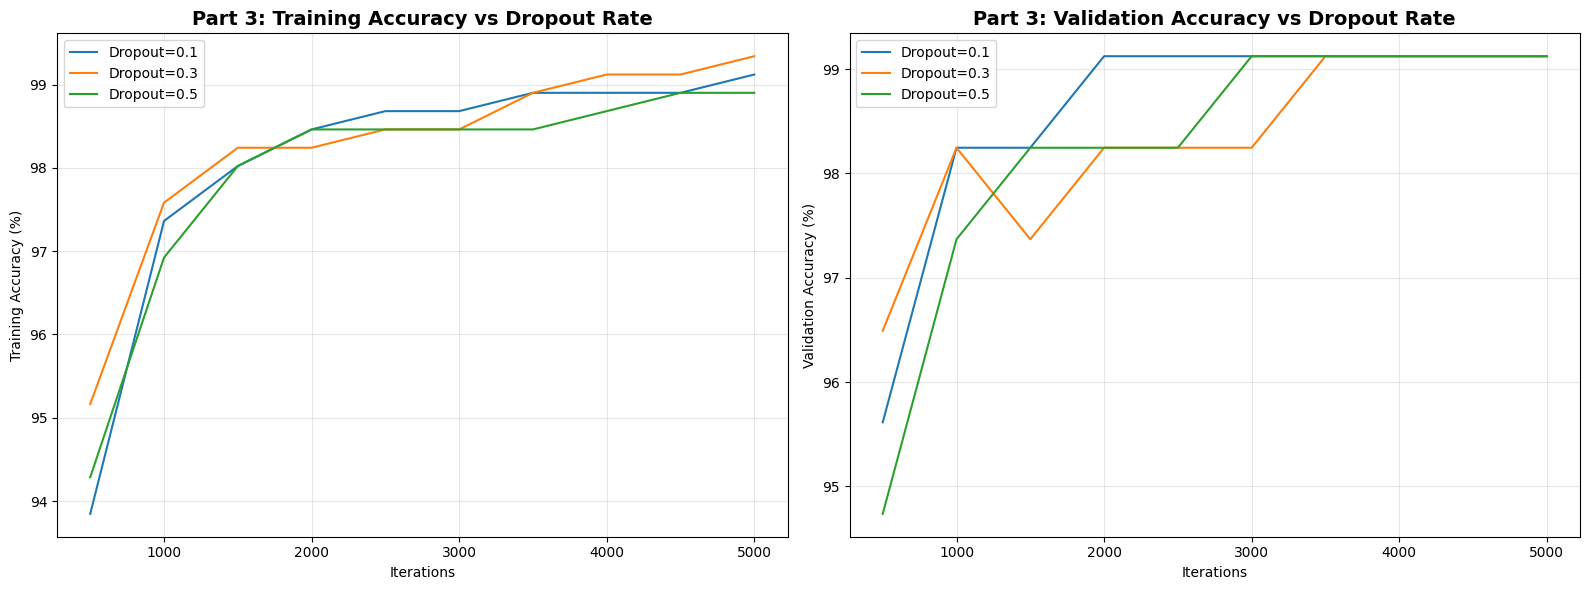

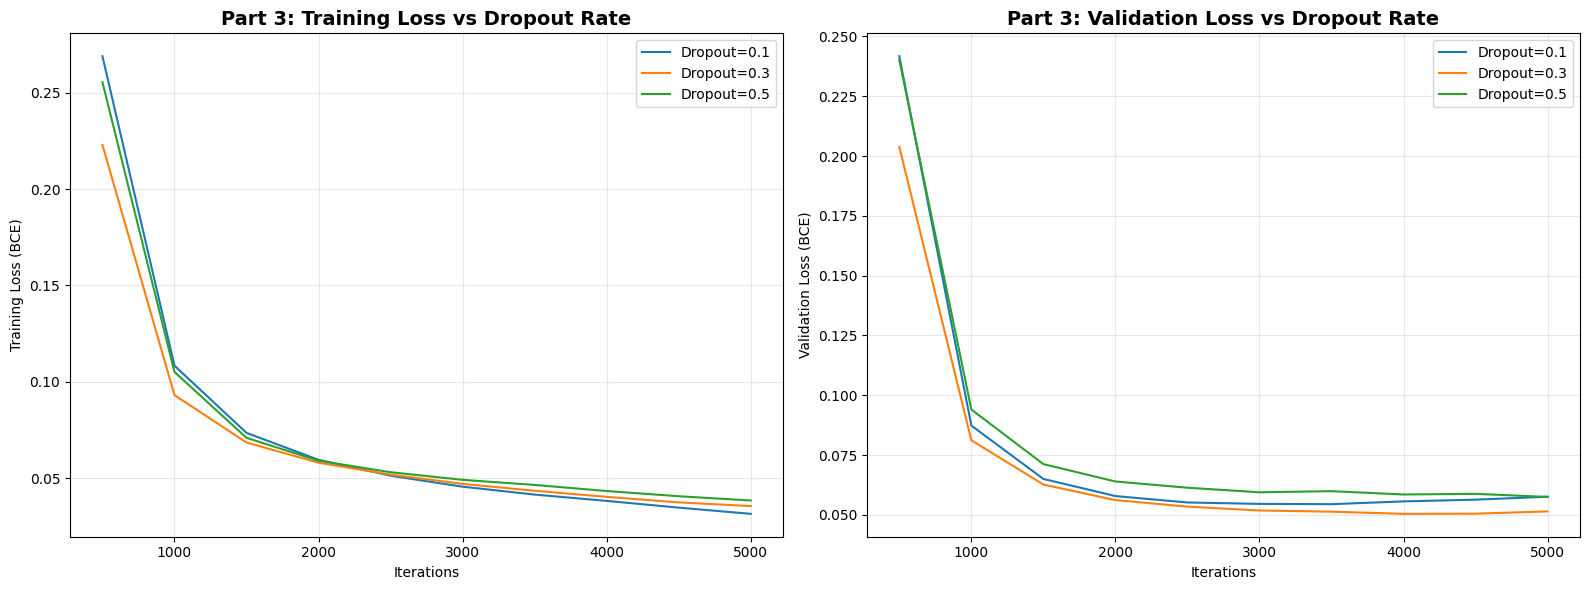

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot accuracies/validations vs dropouts
# CODE HERE: inject points in plots
for rate in dropout_results:
    result = dropout_results[rate]
    axes[0].plot(result['iterations'], [a*100 for a in result['train_accs']], label = f'Dropout={rate}')
    

axes[0].set_title('Part 3: Training Accuracy vs Dropout Rate', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Iterations')
axes[0].set_ylabel('Training Accuracy (%)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)


# CODE HERE: inject points in plots
for rate in dropout_results:
    result = dropout_results[rate]
    axes[1].plot(result['iterations'], [a*100 for a in result['val_accs']], label = f'Dropout={rate}')

axes[1].set_title('Part 3: Validation Accuracy vs Dropout Rate', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Iterations')
axes[1].set_ylabel('Validation Accuracy (%)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for rate in dropout_results:
    result = dropout_results[rate]
    axes[0].plot(result['iterations'], result['train_losses'], label=f'Dropout={rate}')
    

axes[0].set_title('Part 3: Training Loss vs Dropout Rate', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Iterations')
axes[0].set_ylabel('Training Loss (BCE)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

for rate in dropout_results:
    result = dropout_results[rate]
    axes[1].plot(result['iterations'], result['val_losses'], label=f'Dropout={rate}')

axes[1].set_title('Part 3: Validation Loss vs Dropout Rate', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Iterations')
axes[1].set_ylabel('Validation Loss (BCE)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [36]:
# CODE HERE: Create a summary dataframe with the following columns:

dropout_summary = {
    'Dropout Rate': [],
    'Final Train Acc (%)': [],
    'Final Val Acc (%)': [],
    'Final Train Loss': [],
    'Final Val Loss': []
}

# CODE HERE: Fill the summary dictionary by looping through DROPOUT_RATES
for rate in DROPOUT_RATES:
    result = dropout_results[rate]
    dropout_summary['Dropout Rate'].append(rate)
    dropout_summary['Final Train Acc (%)'].append(result['train_accs'][-1] * 100)
    dropout_summary['Final Val Acc (%)'].append(result['val_accs'][-1] * 100)
    dropout_summary['Final Train Loss'].append(result['train_losses'][-1])
    dropout_summary['Final Val Loss'].append(result['val_losses'][-1])


dropout_df = pd.DataFrame(dropout_summary)
display(dropout_df)



,Dropout Rate,Final Train Acc (%),Final Val Acc (%),Final Train Loss,Final Val Loss
0,0.1,99.120879,99.122807,0.031430,0.057558
1,0.3,99.340659,99.122807,0.035462,0.051421
2,0.5,98.901099,99.122807,0.038359,0.057468


#EXPLAIN HERE: Based on your results, answer the following questions:


1. Which dropout rate shows the best generalization (smallest gap between training and validation accuracy)?

Although all 3 rates are generally very close to each other (due to the low numbers of samples in the dataset), Dropout=0.1 yields the smallest gap between training and validation accuracy, being nearly identical. This displays that it generally performs the best out of the 3 rates and there is less overfitting with it.

2. Which dropout rate would you recommend for this dataset and why?

As all 3 dropout rates yield high results, any could be chosen for this particular dataset. However if I were to pick one over others, the dropout rate of 0.3 offers the lowest validation loss which would suggest it has the best calibration of the predicted probabilities as compared to the others.

3. What are the trade-offs between low dropout (0.1) and high dropout (0.5)?

Low dropout tends to have better generalization (smallest gap between training and validation accuracy). It also has less overall training loss but it may tend to overfit in noisier datasets. For high dropouts, it would be less prone to overfitting and may force more simpler generalizations. However, it can also decrease training accuracy which could cause its validation loss to shoot higher.


***Part 4***

In [37]:
def train_with_minibatch_l2(model, criterion, optimizer, X_train, y_train, X_val, y_val,
                            num_iterations, batch_size, check_every):
    """
    #TODO: Implement training with L2 regularization.

    """
    n_samples = X_train.shape[0]
    train_losses, val_losses, iterations = [], [], []

    X_train_shuffled = X_train.clone()
    y_train_shuffled = y_train.clone()
    current_idx = 0

    for i in range(num_iterations + 1):
        if current_idx + batch_size > n_samples:
            X_train_np, y_train_np = shuffle(X_train_shuffled.numpy(), y_train_shuffled.numpy(),
                                            random_state=random_seed + i)
            X_train_shuffled = torch.tensor(X_train_np, dtype=torch.float32)
            y_train_shuffled = torch.tensor(y_train_np, dtype=torch.float32)
            current_idx = 0

        X_batch = X_train_shuffled[current_idx : current_idx + batch_size]
        y_batch = y_train_shuffled[current_idx : current_idx + batch_size]
        current_idx += batch_size

        # CODE HERE: Complete the training
        #forward pass
        optimizer.zero_grad()
        model.train()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)

        #backward pass
        loss.backward()
        optimizer.step() #L2 regularization applied with optimizer.weight_decay later in code

        if i % check_every == 0:
            # CODE HERE: Calculate and store training and validation losses
            model.eval()
            with torch.no_grad():
                train_loss = calculate_full_loss(model, criterion, X_train, y_train)
                val_loss = calculate_full_loss(model, criterion, X_val, y_val)
            train_losses.append(train_loss)
            val_losses.append(val_loss)
            iterations.append(i)
            model.train()
            #pass

    return train_losses, val_losses, iterations


In [38]:
def train_with_minibatch_l1(model, criterion, optimizer, X_train, y_train, X_val, y_val,
                            num_iterations, batch_size, check_every, lambda_l1):
    """
    TODO: Implement training with manual L1 regularization.
    """
    n_samples = X_train.shape[0]
    train_losses, val_losses, iterations = [], [], []

    X_train_shuffled = X_train.clone()
    y_train_shuffled = y_train.clone()
    current_idx = 0

    for i in range(num_iterations + 1):
        if current_idx + batch_size > n_samples:
            X_train_np, y_train_np = shuffle(X_train_shuffled.numpy(), y_train_shuffled.numpy(),
                                            random_state=random_seed + i)
            X_train_shuffled = torch.tensor(X_train_np, dtype=torch.float32)
            y_train_shuffled = torch.tensor(y_train_np, dtype=torch.float32)
            current_idx = 0

        X_batch = X_train_shuffled[current_idx : current_idx + batch_size]
        y_batch = y_train_shuffled[current_idx : current_idx + batch_size]
        current_idx += batch_size

        model.train()
        optimizer.zero_grad()

        # CODE HERE: Calculate outputs and BCE loss
        outputs = model(X_batch)  # REPLACE WITH YOUR CODE
        loss = criterion(outputs, y_batch)  # REPLACE WITH YOUR CODE

        # CODE HERE: Calculate L1 penalty

        l1_penalty = 0
        for param in model.parameters():
            l1_penalty = l1_penalty + torch.sum(torch.abs(param))

        # CODE HERE: Calculate total loss
        total_loss = loss + lambda_l1 * l1_penalty  # REPLACE WITH YOUR CODE

        # TODO: Backpropagate and update weights using total_loss
        total_loss.backward()
        optimizer.step()

        if i % check_every == 0:
            # CODE HERE: Calculate losses
            model.eval()
            with torch.no_grad():
                train_loss = calculate_full_loss(model, criterion, X_train, y_train)
                val_loss = calculate_full_loss(model, criterion, X_val, y_val)
            train_losses.append(train_loss)
            val_losses.append(val_loss)
            iterations.append(i)
            model.train()
            #pass

    return train_losses, val_losses, iterations

In [39]:
LAMBDA_L2_VALUES = [0.0, 1e-4, 1e-3]
LEARNING_RATE_L2 = 0.01
NUM_ITERATIONS_L2 = 5000
BATCH_SIZE_L2 = 32
CHECK_EVERY_L2 = NUM_ITERATIONS_L2 // 10

l2_results = {}

for lambda_l2 in LAMBDA_L2_VALUES:
    print(f"\n--- Training with L2 λ = {lambda_l2} ---")

    # CODE HERE: Initialize & train the model (use original FeedForwardNet, no dropout)
    model = BreastCancerNN(input_features)
    criterion = torch.nn.BCELoss()
    optimizer = torch.optim.SGD(model.parameters(), lr=LEARNING_RATE_L2, weight_decay=lambda_l2)

    train_losses, val_losses, iterations = train_with_minibatch_l2(
        model, criterion, optimizer,
        X_train_t, y_train_t, X_val_t, y_val_t,
        NUM_ITERATIONS_L2, BATCH_SIZE_L2, CHECK_EVERY_L2
    )

    # CODE HERE: Calculate final validation accuracy
    final_accuracy = calculate_accuracy(model, X_val_t, y_val_t)

    # Store results
    l2_results[lambda_l2] = {
        'train_losses': train_losses,
        'val_losses': val_losses,
        'iterations': iterations,
        'final_accuracy': final_accuracy,
        'model': model
    }

    print(f"Final Validation Accuracy: {final_accuracy*100:.2f}%")


--- Training with L2 λ = 0.0 ---
Final Validation Accuracy: 99.12%

--- Training with L2 λ = 0.0001 ---
Final Validation Accuracy: 99.12%

--- Training with L2 λ = 0.001 ---
Final Validation Accuracy: 98.25%


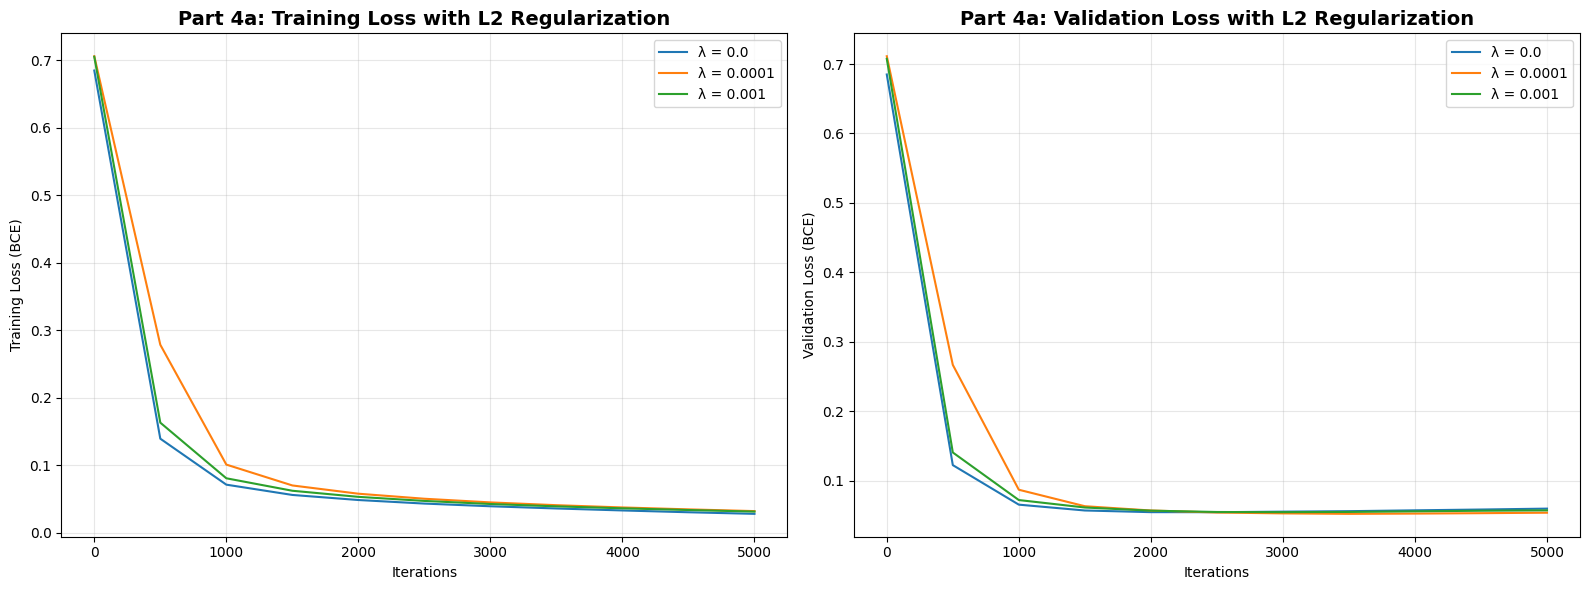

In [40]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# TODO: Plot training/validation loss for all L2 values
# CODE HERE: Inject points to plots
for lambda_l2 in LAMBDA_L2_VALUES:
    result = l2_results[lambda_l2]
    axes[0].plot(result['iterations'], result['train_losses'], label=f'λ = {lambda_l2}')

axes[0].set_title('Part 4a: Training Loss with L2 Regularization', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Iterations')
axes[0].set_ylabel('Training Loss (BCE)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# CODE HERE: Inject points to plots
for lambda_l2 in LAMBDA_L2_VALUES:
    result = l2_results[lambda_l2]
    axes[1].plot(result['iterations'], result['val_losses'], label=f'λ = {lambda_l2}')

axes[1].set_title('Part 4a: Validation Loss with L2 Regularization', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Iterations')
axes[1].set_ylabel('Validation Loss (BCE)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [41]:
LAMBDA_L1 = 1e-4

# CODE HERE : Initialize model, criterion, and optimizer for L1 experiment
model_l1 = BreastCancerNN(input_features)
criterion_l1 = torch.nn.BCELoss()
optimizer_l1 = torch.optim.SGD(model_l1.parameters(), lr = LEARNING_RATE_L2)

# Train with L1
train_losses_l1, val_losses_l1, iterations_l1 = train_with_minibatch_l1(
    model_l1, criterion_l1, optimizer_l1,
    X_train_t, y_train_t, X_val_t, y_val_t,
    NUM_ITERATIONS_L2, BATCH_SIZE_L2, CHECK_EVERY_L2, LAMBDA_L1
)

# CODE HERE: Calculate final validation accuracy for L1 model
final_accuracy_l1 = calculate_accuracy(model_l1, X_val_t, y_val_t)

print(f"Final Validation Accuracy (L1): {final_accuracy_l1*100:.2f}%")

Final Validation Accuracy (L1): 99.12%


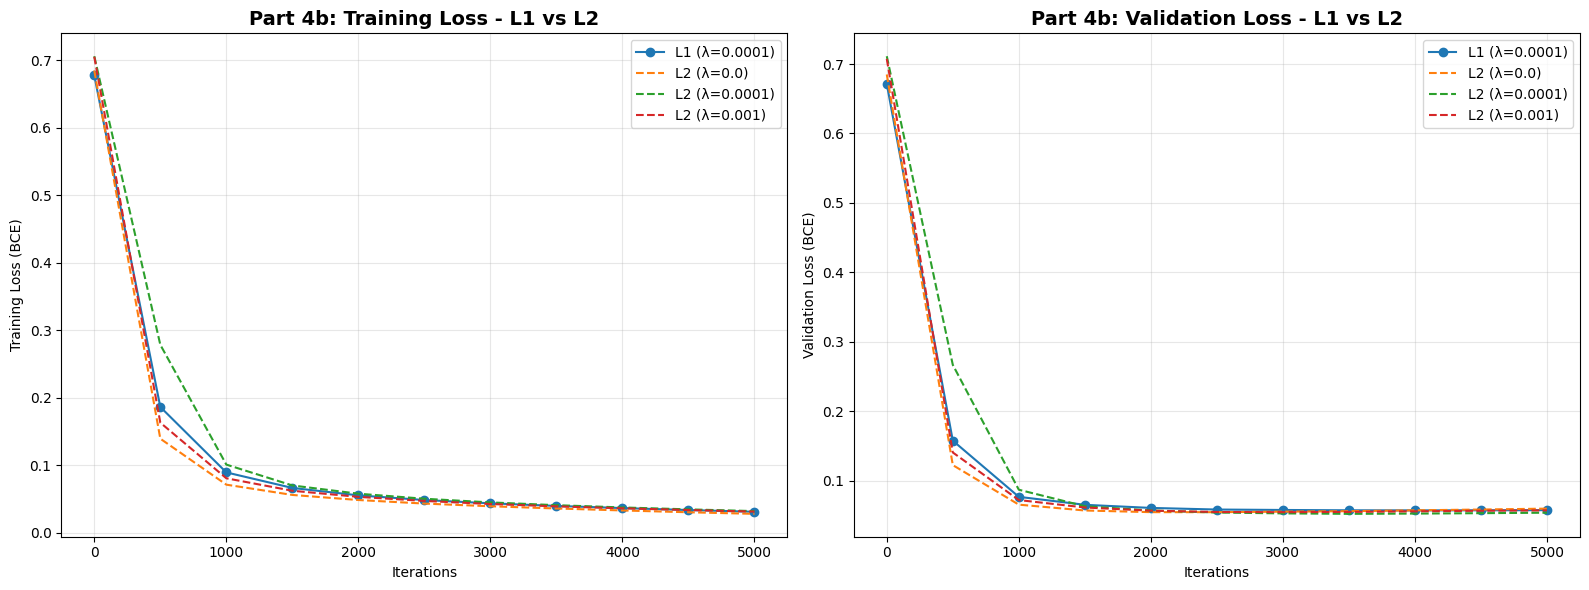

In [42]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# CODE HERE: inject points to plots
# Plot L1
axes[0].plot(iterations_l1, train_losses_l1, label=f'L1 (λ={LAMBDA_L1})', linestyle='-', marker='o')

# Plot each L2 curve
for lambda_l2 in LAMBDA_L2_VALUES:
    result = l2_results[lambda_l2]
    axes[0].plot(result['iterations'], result['train_losses'], label=f'L2 (λ={lambda_l2})', linestyle='--')

axes[0].set_title('Part 4b: Training Loss - L1 vs L2', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Iterations')
axes[0].set_ylabel('Training Loss (BCE)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# CODE HERE: inject points to plots
axes[1].plot(iterations_l1, val_losses_l1, label=f'L1 (λ={LAMBDA_L1})', linestyle='-', marker='o')

# Plot each L2 curve
for lambda_l2 in LAMBDA_L2_VALUES:
    result = l2_results[lambda_l2]
    axes[1].plot(result['iterations'], result['val_losses'], label=f'L2 (λ={lambda_l2})', linestyle='--')

axes[1].set_title('Part 4b: Validation Loss - L1 vs L2', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Iterations')
axes[1].set_ylabel('Validation Loss (BCE)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [43]:

# TODO: Create a summary dataframe with columns:
# Fill rows for: No regularization, L2 (1e-4), L2 (1e-3), L1 (1e-4)
# CODE HERE

reg_summary = {
    'Regularization': [],
    'Final Val Acc (%)': [],
    'Final Train Loss': [],
    'Final Val Loss': [],
    'Sparsity (%)': []
}

# TODO: Fill the summary dictionary
# CODE HERE

def calculate_sparsity(model, threshold=1e-3):
    total = 0
    zeros = 0
    for param in model.parameters():
        total += param.numel() # total parameters
        zeros += (param.abs() < threshold).sum().item() # how many of params are near 0 given threshold value
    
    if total > 0:
        sparsity = (zeros / total) * 100 # number of zero-value divided by total = sparcity
    else:
        sparsity = 0

    return sparsity 

# No regularization
no_regularization = l2_results[0]
reg_summary['Regularization'].append('No regularization')
reg_summary['Final Val Acc (%)'].append(no_regularization['final_accuracy'] * 100)
reg_summary['Final Train Loss'].append(no_regularization['train_losses'][-1])
reg_summary['Final Val Loss'].append(no_regularization['val_losses'][-1])
reg_summary['Sparsity (%)'].append(calculate_sparsity(no_regularization['model']))

# L2 -> λ=1e-4
l2_1e4 = l2_results[1e-4]
reg_summary['Regularization'].append('L2 -> λ=1e-4')
reg_summary['Final Val Acc (%)'].append(l2_1e4['final_accuracy'] * 100)
reg_summary['Final Train Loss'].append(l2_1e4['train_losses'][-1])
reg_summary['Final Val Loss'].append(l2_1e4['val_losses'][-1])
reg_summary['Sparsity (%)'].append(calculate_sparsity(l2_1e4['model']))

# L2 -> λ=1e-3
l2_1e3 = l2_results[1e-3]
reg_summary['Regularization'].append('L2  -> λ=1e-3')
reg_summary['Final Val Acc (%)'].append(l2_1e3['final_accuracy'] * 100)
reg_summary['Final Train Loss'].append(l2_1e3['train_losses'][-1])
reg_summary['Final Val Loss'].append(l2_1e3['val_losses'][-1])
reg_summary['Sparsity (%)'].append(calculate_sparsity(l2_1e3['model']))

# L1 -> λ=1e-4
reg_summary['Regularization'].append('L1 -> λ=1e-4')
reg_summary['Final Val Acc (%)'].append(final_accuracy_l1 * 100)
reg_summary['Final Train Loss'].append(train_losses_l1[-1])
reg_summary['Final Val Loss'].append(val_losses_l1[-1])
reg_summary['Sparsity (%)'].append(calculate_sparsity(model_l1))

reg_df = pd.DataFrame(reg_summary)
display(reg_df)

,Regularization,Final Val Acc (%),Final Train Loss,Final Val Loss,Sparsity (%)
0,No regularization,99.122807,0.028312,0.059935,0.520494
1,L2 -> λ=1e-4,99.122807,0.032370,0.054061,0.585556
2,L2 -> λ=1e-3,98.245614,0.031649,0.057455,0.650618
3,L1 -> λ=1e-4,99.122807,0.031352,0.057764,1.691607



#EXPLAIN HERE: Based on your experiments, answer the following questions:


1. What happens when you increase L2 strength from λ=1e-4 to λ=1e-3?

Increasing λ to 1e-3 yields a lower final validation accuracy which in turn increases final validation loss and sparsity. In general, having higher L2 means results are more sparse and can potentially lead to underfitting if its too high. There is generally a sweet spot to having an L2 strength, too little can lead to overfitting while too high can lead to underfitting. In our case, it seems like 1e-3 tends to slightly underfit the data more.
   
2. Which regularization method (L1/L2 or no regulation) achieves better generalization for this breast cancer dataset?

L2 = 1e-4 achieves better generalization in the breast cancer dataset. This is shown through it having the least amount of final validation loss even if it risks losing some more loss in training. It shows that it tends to overfit less than no regularization but doesn't underfit as much as L2 = 1e-3 or L1. L1 also increases sparsity by a lot more which is generally not the best while L2 = 1e-4 keeps similar loss values.
   